In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import eloUtils
import gc

### Importing Data

In [2]:
#Data obtained from this script https://github.com/Nathanlauga/nba-data-scrapping/
games = pd.read_csv('games.csv',nrows=26300)
games_details = pd.read_csv('games_details.csv')
players = pd.read_csv('players.csv')
teams = pd.read_csv('teams.csv')
ranking = pd.read_csv('ranking.csv')

#Filtering games from 2006 onwards
games = games.loc[(games['SEASON']>= 2006)]



/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_3166/2459834105.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  games_details = pd.read_csv('games_details.csv')


In [3]:
games.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-14,22200414,Final,1610612766,1610612765,2022,1610612766,134.0,0.412,0.793,...,21.0,52.0,1610612765,141.0,0.516,0.750,0.450,25.0,52.0,0
1,2022-12-14,22200415,Final,1610612754,1610612744,2022,1610612754,125.0,0.506,0.840,...,30.0,34.0,1610612744,119.0,0.465,0.862,0.424,27.0,46.0,1
2,2022-12-14,22200416,Final,1610612753,1610612737,2022,1610612753,135.0,0.505,0.833,...,28.0,46.0,1610612737,124.0,0.500,0.889,0.343,30.0,39.0,1
3,2022-12-14,22200417,Final,1610612761,1610612758,2022,1610612761,123.0,0.500,0.852,...,25.0,39.0,1610612758,124.0,0.484,0.850,0.370,29.0,50.0,0
4,2022-12-14,22200418,Final,1610612741,1610612752,2022,1610612741,120.0,0.548,0.864,...,25.0,31.0,1610612752,128.0,0.495,0.800,0.529,25.0,48.0,0


In [4]:
gc.collect()

0

The graph below shows all of the games in each season that are in the dataset.

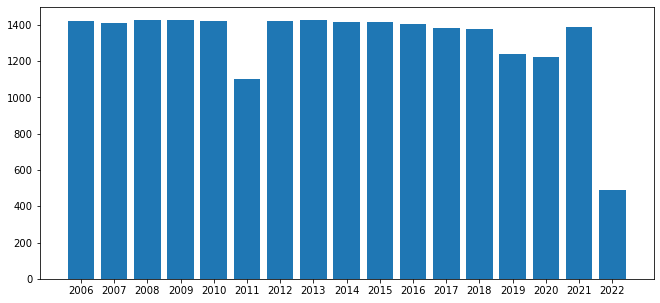

In [5]:
fig, ax = plt.subplots(figsize=(11,5))

v_c = games['SEASON'].value_counts().sort_index()
v_c.index = v_c.index.astype(str)
ax.bar(v_c.index, v_c.values)

plt.show()

### Feature Creation

The get avg_stats_last_n_games function returns a rolling average of teams stats in the past n games. For example, it will return the average points, rebounds, assists, etc. of a certain team in the past n games per game.

In [6]:
def get_avg_stats_last_n_games(team, game_date, season_team_stats, n) :
  prev_game_df = season_team_stats[(season_team_stats['GAME_DATE_EST'] < game_date) & (season_team_stats['TEAM_ID_home'] == team) | (season_team_stats['TEAM_ID_home'] == team)].head(n)
  data = []
  for index,prev_game_row in prev_game_df.iterrows():
    if(prev_game_row['TEAM_ID_home'] == team):
        h_df = prev_game_row[[7,8,9,10,11,12]]
        data.append(h_df.tolist())
            #h_df.columns = [x[2:] for x in h_df.columns]   
    if(prev_game_row['TEAM_ID_away']==team):
        a_df = prev_game_row[[14,15,16,17,18,19]]
        data.append(a_df.tolist())
  ndf = pd.DataFrame(data, columns=['PTS', 'FG_PCT', 'FT_PCT','FG3_PCT','AST','REB'])          

  return ndf.mean()

The eloUtils.py file contains the helper methods to calculate a teams elo before every game in the past 20 years and reset each teams ELO after each season. Having the file in the working directory should be fine, which would allow this notebook to find the helper functions. The cell below creates features for each game. Each team's elo is calculated before the game and stored in a dataframe as features to be used in the classifier.

In [7]:
#Code to calculate ELO adapted from this article https://medium.com/mlearning-ai/how-to-calculate-elo-score-for-international-teams-using-python-66c136f01048


# Creating the empty dictionary that is going to store the current elo for each team
import eloUtils
current_elo={}
recentTeamPerformance = {}
games =  games.loc[::-1]
performance_data = []
recent_performance_df = pd.DataFrame()
curr_season = 2003
for idx,row in games.iterrows():
    # Getting the data that it is nedeed to calculate the elo 
    home=row['TEAM_ID_home']
    away=row['TEAM_ID_away']
    home_pts=row['PTS_home']
    away_pts=row['PTS_away']
    game_date = row['GAME_DATE_EST']
    game_id = row['GAME_ID']
    season = row['SEASON']
    
    if season != curr_season:
        curr_season = season
        for key in current_elo.keys():
            final_season_elo = current_elo[key]
            current_elo[key] = eloUtils.soft_reset(final_season_elo)



    # Getting elo before match. If it is the first match played, the elo is initialized in 1500.
    if home not in current_elo.keys():
        current_elo[home]=1500
    
    if away not in current_elo.keys():
        current_elo[away]=1500
    
    #calculating and updating elo
    elo_h=current_elo[home]
    elo_aw=current_elo[away]
    elo_ln,elo_vn=eloUtils.calculate_elo(elo_h,elo_aw,home_pts,away_pts)

    current_elo[home]=elo_ln
    current_elo[away]=elo_vn

    h_team_recent_performance = get_avg_stats_last_n_games(home, game_date, games, 10)
    #h_team_recent_performance.index = ['H_Last_10_Avg_' + x for x in h_team_recent_performance.index]
    recentTeamPerformance[home]=h_team_recent_performance.tolist()


    a_team_recent_performance = get_avg_stats_last_n_games(away, game_date, games, 10)
    recentTeamPerformance[away] = a_team_recent_performance.tolist()
    
    #a_team_recent_performance.index = ['A_Last_10_Avg_' + x for x in a_team_recent_performance.index]
    performance_data.append(h_team_recent_performance.tolist() +a_team_recent_performance.tolist())

    
    #Saving results in dataframe
    games.loc[idx,'Elo_h_after']=elo_ln
    games.loc[idx,'Elo_a_after']=elo_vn 
    games.loc[idx,'Elo_h_before']=elo_h
    games.loc[idx,'Elo_a_before']=elo_aw

    
recent_performance_df = pd.DataFrame(performance_data, columns= ['H_Last_10_Avg_PTS', 'H_Last_10_Avg_FG_PCT', 'H_Last_10_Avg_FT_PCT','H_Last_10_Avg_FG3_PCT','H_Last_10_Avg_AST','H_Last_10_Avg_REB','A_Last_10_Avg_PTS', 'A_Last_10_Avg_FG_PCT', 'A_Last_10_Avg_FT_PCT','A_Last_10_Avg_FG3_PCT','A_Last_10_Avg_AST','A_Last_10_Avg_REB'])
recent_performance_df.reset_index(drop=True, inplace=True)
games.reset_index(drop=True, inplace=True)
featureGames = pd.concat([games, recent_performance_df], axis = 1)
games =  games.loc[::-1]
featureGames =  featureGames.loc[::-1]


In [8]:
# x = [pd.to_datetime(d) for d in x]
# fig, ax = plt.subplots(figsize=(11,5))
# ax.scatter(x,y)
# plt.show()
#Test code to graph a team's elo throughout the past 20 years.

The code below creates the features, which are each team's average stats in the past 10 games, and each team's elo before the game. It also creates the label, which is whether or not the home team wins. So if the model outputs 1, then it predicts that the home team will win, and if it is 0, it predicts that the away team will win.

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import normalize, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.pipeline import Pipeline



cols = ['Elo_h_before','Elo_a_before','H_Last_10_Avg_PTS', 'H_Last_10_Avg_FG_PCT', 'H_Last_10_Avg_FT_PCT','H_Last_10_Avg_FG3_PCT','H_Last_10_Avg_AST','H_Last_10_Avg_REB','A_Last_10_Avg_PTS', 'A_Last_10_Avg_FG_PCT', 'A_Last_10_Avg_FT_PCT','A_Last_10_Avg_FG3_PCT','A_Last_10_Avg_AST','A_Last_10_Avg_REB']

features = featureGames[cols].values
label = games['HOME_TEAM_WINS'].values


/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Data Analysis:

In this section, I test the performance of Gaussian Native Bayes, K-Nearest Neighbors, Decision Tree, Random Forest, Multilayer Perceptron, and an Ensemble of the best performers. ELO already gives a good idea of a team's likelihood of winning, where if the model simply picked the team with the highest ELO, it will often result in an accurate prediction most of the time. Focusing more on improving the F1-score of the model would reduce the number of false positives and negatives, and would be a better metric to evaluate the overall performance of the model. 

In [11]:
from sklearn.metrics import make_scorer,f1_score
# features_pca = PCA(14).fit_transform(features_scaled)
x_train, x_test, y_train, y_test = train_test_split(features, label, test_size = 0.2)
# x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.1)

scorer = make_scorer(f1_score, pos_label=None, average='weighted')

In [50]:
from sklearn.naive_bayes import GaussianNB
pipelineNB= Pipeline([('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', GaussianNB())])
                   
pipelineNB.fit(x_train, y_train)
y_train_NB = pipelineNB.predict(x_train)
y_pred_NB = pipelineNB.predict(x_test)



In [51]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_NB)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_NB)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_NB)))

Train Accuracy score: 0.660786065207682
Test Accuracy score: 0.6686760437597679
Test F1 score: 0.741102581995813


In [14]:
from sklearn import tree
pipelineCLF= Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', tree.DecisionTreeClassifier())])
                   
pipelineCLF.fit(x_train, y_train)
y_train_CLF = pipelineCLF.predict(x_train)
y_pred_CLF = pipelineCLF.predict(x_test)


In [15]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_CLF)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_CLF)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_CLF)))

Train Accuracy score: 1.0
Test Accuracy score: 0.5708863585621791
Test F1 score: 0.6295296838858905


In [16]:
from sklearn.neighbors import KNeighborsClassifier
pipelineKNN = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', KNeighborsClassifier(n_neighbors=3))])
                   
pipelineKNN.fit(x_train, y_train)
y_train_KNN = pipelineKNN.predict(x_train)
y_pred_KNN = pipelineKNN.predict(x_test)


In [17]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_KNN)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_KNN)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_KNN)))

Train Accuracy score: 0.7867351496203663
Test Accuracy score: 0.6010270149586961
Test F1 score: 0.6693802035152636


In [56]:
pipelinerf = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', RandomForestClassifier())])

pipelinerf.fit(x_train, y_train)
y_train_rf = pipelinerf.predict(x_train)
y_pred_rf = pipelinerf.predict(x_test)


In [58]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_rf)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_rf)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_rf)))

Train Accuracy score: 1.0
Test Accuracy score: 0.6153159187318598
Test F1 score: 0.681339004993527


In [39]:
from sklearn.neural_network import MLPClassifier
mlppipeline = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',MLPClassifier(hidden_layer_sizes=(100,)))])

mlppipeline.fit(x_train, y_train)
y_train_mlp = mlppipeline.predict(x_train)
y_pred_mlp = mlppipeline.predict(x_test)

print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_mlp)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_mlp)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_mlp)))

Train Accuracy score: 0.6902635104957571
Test Accuracy score: 0.6496985934360349
Test F1 score: 0.7183629509962305


/opt/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


The base Naive Bayes model performed the best out of the following models, with an accuracy of 66.8% on the test set, and a F1 score of .74. The Multilayer Perceptron performed the second best, with an accuracy of 64.9% and an F1-score of .71. The base RandomForestClassifier performed third best, with an an accuracy of 61% and an F1-score of .68. 

Optimizing Gaussian NB and Random Forest

In [54]:
#Tuning GaussianNB Code from: https://stackoverflow.com/questions/39828535/how-to-tune-gaussiannb
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
import numpy as np
params_NB = {
    'clf__priors': [None],
    'clf__var_smoothing': np.logspace(0,-9, num=100)
}

gs_NB = GridSearchCV(estimator=pipelineNB, 
                 param_grid=params_NB, 
                 cv=10,   # use any cross validation technique 
                 verbose=1, 
                 scoring='f1') 
gs_NB.fit(x_train, y_train)
print(gs_NB.best_estimator_)
y_train_NB_GS = gs_NB.predict(x_train)
y_pred_NB_GS = gs_NB.predict(x_test)

#the code returns different hyperparameters


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Pipeline(steps=[('scaler', RobustScaler()), ('pca', PCA(n_components=14)),
                ('clf', GaussianNB(var_smoothing=0.533669923120631))])


In [55]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_NB_GS)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_NB_GS)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_NB_GS)))
# print('Average Decision Tree F1: {}'.format((cross_val_score(gs_NB, x_train, y_train, scoring=scorer)).mean()))

Train Accuracy score: 0.6389012952210809
Test Accuracy score: 0.6358562179057825
Test F1 score: 0.7501149073081047


While tuning the Gaussian NB model did improve my F1 score by .01, the accuracy dropped by about 3%, which is quite a large tradeoff between accuracy and F1.

Code to tune the random forest model using random search. Taken from this [github](https://github.com/JoshWeiner/NBA_Game_Prediction/blob/main/CIS_545_Final_Project.ipynb).

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 0, stop = 2000, num = 11)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(0, 100, num = 6)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'clf__n_estimators': n_estimators,
               'clf__max_features': max_features,
               'clf__max_depth': max_depth,
               'clf__min_samples_split': min_samples_split,
               'clf__min_samples_leaf': min_samples_leaf,
               'clf__bootstrap': bootstrap}


# Use the random grid to search for best hyperparameters

# Random search of parameters, using 2-fold cross validation, 
# search across 100 different combinations, and use all available cores
rfc_random = RandomizedSearchCV(estimator = pipelinerf, param_distributions = random_grid, n_iter = 100, cv = 2, verbose=2, n_jobs = -1)
# Fit the random search model
rfc_random.fit(x_train, y_train)
y_pred_rfr_random = rfc_random.predict(x_test)
print(metrics.accuracy_score(y_test, y_pred_rfr_random))
print (rfc_random.best_estimator_)


In [59]:
pipelinetrf = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt', min_samples_leaf=4,
                         min_samples_split=4, n_estimators=473, n_jobs=2))])

pipelinetrf.fit(x_train, y_train)
y_train_trf = pipelinetrf.predict(x_train)
y_pred_trf = pipelinetrf.predict(x_test)

In [60]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_trf)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_trf)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_trf)))

Train Accuracy score: 0.6323693613220187
Test Accuracy score: 0.6246930118329984
Test F1 score: 0.7451872063058967


The tuned Random Forest model performed much better, with an accuracy of 62.4% and a F1 score of .74

In [62]:
from sklearn.calibration import CalibratedClassifierCV
isotonicRFC = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',CalibratedClassifierCV(pipelinetrf,cv = 5, method = "isotonic"))])

isotonicRFC.fit(x_train, y_train)
y_train_iso = isotonicRFC.predict(x_train)
y_pred_iso = isotonicRFC.predict(x_test)


/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [63]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_iso)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_iso)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_iso)))

Train Accuracy score: 0.6629633765073694
Test Accuracy score: 0.657289573565528
Test F1 score: 0.7353904499224272


Interestingly, after calibration, the accuracy score of the tuned Random Forest model performed much better even after hyperparameter tuning with an accuracy score of 65.7% and a F1 score of .735. The accuracy improved by over 3% with only a drop of .005 in F1 score.

In the following cells, I test if Bagging, Boosting, and Soft Voting will improve the accuracy and F1 scores of my models.

In [64]:
from sklearn.ensemble import BaggingClassifier,GradientBoostingClassifier


pipelineBagrf= BaggingClassifier(pipelinetrf)

pipelineBagNB= BaggingClassifier(pipelineNB)
                   
pipelineBagrf.fit(x_train, y_train)
y_train_Bagrf = pipelineBagrf.predict(x_train)
y_pred_Bagrf = pipelineBagrf.predict(x_test)

pipelineBagNB.fit(x_train, y_train)
y_train_BagNB = pipelineBagNB.predict(x_train)
y_pred_BagNB = pipelineBagNB.predict(x_test)


/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [65]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_Bagrf)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_Bagrf)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_Bagrf)))

print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_BagNB)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_BagNB)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_BagNB)))

Train Accuracy score: 0.6354957570343903
Test Accuracy score: 0.6271489171690109
Test F1 score: 0.7450381679389313
Train Accuracy score: 0.6600044662795891
Test Accuracy score: 0.6702388926099576
Test F1 score: 0.7420988301030207


In [35]:
pipelineBoostNB= GradientBoostingClassifier(init = pipelineNB)
pipelineBoostNB.fit(x_train, y_train)
y_train_BoostNB = pipelineBoostNB.predict(x_train)
y_pred_BoostNB = pipelineBoostNB.predict(x_test)

print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_BoostNB)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_BoostNB)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_BoostNB)))


Train Accuracy score: 0.6744640464493077
Test Accuracy score: 0.6688993078812235
Test F1 score: 0.7373826810695945


Bagging with the Gaussian NB model raised the accuracy score to 67%, with a similar F1 score of .74. Bagging on the Random Forest model worsened the accuracy score compared to the calibrated Random Forest, even though the F1 scores did increase. Boosting with the Gaussian NB model did not significantly improve the model compared to the base Gaussian NB model.

I initially wanted to see how well stacking would perform, however after reading [an article on voting vs. stacking](https://towardsdatascience.com/ensemble-methods-comparing-scikit-learns-voting-classifier-to-the-stacking-classifier-f5ab1ed1a29d), I decided to go with soft voting with the top 3 classifers in order to avoid overfitting with stacking. The article mentioned that calibration would work best with soft voting, which uses probabilities, so I used the calibrated versions of the random forest, multilayer perceptron, and gaussian naive bayes in the voting classifier.

In [66]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
isotonicmlp= Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',CalibratedClassifierCV(mlppipeline,cv = 5, method = "isotonic"))])

isotonicNB= Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',CalibratedClassifierCV(pipelineNB,cv = 5, method = "isotonic"))])

#creating an voting ensemble of the top 3 performers.
ensemblevoting = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                    ('clf',VotingClassifier(estimators = [('rf',isotonicRFC), ('mlp',isotonicmlp), ('gnb',isotonicNB)],voting='soft'))])
ensemblevoting.fit(x_train, y_train)
y_train_voting = ensemblevoting.predict(x_train)
y_pred_voting = ensemblevoting.predict(x_test)

print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_voting)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_voting)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_voting)))


/opt/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/neural_network/_multi

Train Accuracy score: 0.6765297007592675
Test Accuracy score: 0.6675597231524893
Test F1 score: 0.7417172593235039


Out of all the ensemble methods, Bagging with the Gaussian NB model slightly improved the accuracy score. The other methods did not improve my model much. I had some expectations that a ensemble of pretty strong learners could show improvement in the accuracy and F1 score, however the ensemble is still similar to the base Gaussian NB model.

In [ ]:
# #This code uses an NBA_API endpoint to obtain today's games and predicts the result of them. Example modified from NBA_API docs: https://github.com/swar/nba_api/blob/master/docs/examples/LiveData.ipynb

# # Query nba.live.endpoints.scoreboard and  list games in localTimeZone
# from datetime import datetime, timezone
# from dateutil import parser
# from nba_api.live.nba.endpoints import scoreboard

# f = "{gameId}:  {awayTeam} vs. {homeTeam} @ {gameTimeLTZ}" 

# board = scoreboard.ScoreBoard()
# print("ScoreBoardDate: " + board.score_board_date)
# games = board.games.get_dict()
# for game in games:
#     gameTimeLTZ = parser.parse(game["gameTimeUTC"]).replace(tzinfo=timezone.utc).astimezone(tz=None)
#     print(f.format(gameId=game['gameId'], awayTeam=game['awayTeam']['teamName'], homeTeam=game['homeTeam']['teamName'], gameTimeLTZ=gameTimeLTZ))
#     print("Away: " + str(current_elo[game['awayTeam']['teamId']]) + " Home: " + str(current_elo[game['homeTeam']['teamId']]))
#     homeTeamPerformance = recentTeamPerformance[game['homeTeam']['teamId']]
#     awayTeamPerformance = recentTeamPerformance[game['awayTeam']['teamId']]
#     inputList = [current_elo[game['homeTeam']['teamId']],current_elo[game['awayTeam']['teamId']]]
#     print('ISORandom Forest Predict: ' + str(isotonicRFC.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('ISORandom Forest Probs: ' +  str(isotonicRFC.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('Random Forest Predict: ' + str(pipelinerf.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('Random Forest Probs: ' +  str(pipelinerf.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('Naive Bayes Predict: ' + str(pipelineNB.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('Naive Bayes Probs: ' + str(pipelineNB.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('\n')

ScoreBoardDate: 2022-12-04
0022200344:  Nuggets vs. Pelicans @ 2022-12-04 15:30:00-05:00
Away: 1541.994188264014 Home: 1616.9267588882112
ISORandom Forest Predict: [1]
ISORandom Forest Probs: [[0.35867574 0.64132426]]
Random Forest Predict: [1]
Random Forest Probs: [[0.34035805 0.65964195]]
Naive Bayes Predict: [1]
Naive Bayes Probs: [[0.30267899 0.69732101]]


0022200345:  Suns vs. Spurs @ 2022-12-04 16:00:00-05:00
Away: 1658.9315082044473 Home: 1323.9292574194753
ISORandom Forest Predict: [0]
ISORandom Forest Probs: [[0.64755793 0.35244207]]
Random Forest Predict: [0]
Random Forest Probs: [[0.53371512 0.46628488]]
Naive Bayes Predict: [0]
Naive Bayes Probs: [[0.75661809 0.24338191]]


0022200346:  Celtics vs. Nets @ 2022-12-04 18:00:00-05:00
Away: 1720.3719307709478 Home: 1538.5915520215192
ISORandom Forest Predict: [0]
ISORandom Forest Probs: [[0.60912751 0.39087249]]
Random Forest Predict: [1]
Random Forest Probs: [[0.49753835 0.50246165]]
Naive Bayes Predict: [0]
Naive Bayes Probs

### Conclusion

Overall, the Gaussian NB model with Bagging performed the best, with an accuracy score of 67% and an F1 score of about .74. The soft voting ensemble performed about the same as the base Gaussian NB model, however it may be better since it does not solely depend on a single model to make the prediction. The overall accuracy seemed to cap out at about 66-67%, and the F1 score about .74-.75. This likely could be due to the limitations of my features, since I only have 14 features, and it may not be fully representative of deciding whether a team wins a certain game or not. I think reaching a 67% accuracy score is quite close to the best models which can predict the correct winner about 70% of the time, and having a fairly high F1 score makes it quite trustworthy. ELo is a strong indicator of whether or not a team will win, however it is not perfect. I wonder if there is a way for the model to reach 80% or if that accuracy rate is impossible due to variance.

### Future Work

One large improvement that can be made to the proejct would be better features that incorporate fatigue and injuries. While Elo does capture some of these factors, it takes a few games for the Elo to correct to the right value, which can result in inaccurate predictions during the time frame. Having a weighted score of the statistical impact of losing injured players and the severity of the injury would hopefully allow the model to better predict which team wins. Also working with calibrated classifiers is interesting, since it is primarily for calibrating the classifier probabilities, which could be more representative of the problem itself. Since no NBA team has a 100% chance of winning, seeing the probabilities for each game could be a better way to understand matchups. Seeing how the probabilities of the model compares to Vegas odds, a market equilibrium of what people think of the probabilities would be interesting to look at.

Predicting Winners of NBA Games (From Prototype Submission)

The project’s goal is to accurately predict whether or not an NBA team wins a given matchup. After researching, it seems the best way to approach this problem is to treat it as a classification problem, since NBA games do not end as a draw, which allows for a binary result.
In order to accomplish this, I have to be able to collect sufficient data, create features from that data that are correlated with the winning potential of a team, and use a tuned model in order to get the best accuracy score. I tested Multilayer Perceptron, K-Nearest Neighbors, Random Forest, and Gaussian NB against each other.

Status/Description:

To get the data, I used a data scraping script I found online and used it to scrape game and player data from NBA.com, which scraped game data from the 2003 NBA season all the way to Today’s NBA Games. The scraper resulted in multiple csv files, but the ones I would be interested in would be games.csv, which contains every game’s team stats and box score for the past 20 years, and games_details.csv which provides player stats for each game, based on game ID. Teams.csv and Player.csv contain data on which teamID and playerID correspond with which team and player.
Through research, I found ELO to be one of the best features to use in determining which team wins, since it is a mathematical relationship between the strength of the teams (Beating tougher opponents raises ELO higher), and is reset each season, giving an edge over season trackers like rankings. I used code to calculate the ELO levels of each world cup team to calculate the historical ELO scores of each NBA team before each NBA game in the past 20 years, and updated the scores after each game as well. For each game, I also averaged the teams’ performance in the past 10 games for each game in order to better account for recent team performance in the context of the matchup, and to somewhat account for star player injuries. From what I researched, the best models that predict NBA outcomes are around the 70% mark. I’d like to see how much tuning the model would improve my output by, and whether or not other classification models would perform better. Since I am only using free, publicly available data, I wonder how close I can get the model to 70%, compared to the models that use paid data. 

Status:

As for what remains to be done, I would like to include player stats in my model, which would help differentiate what players make a specific team good besides aggregated scores like ELO, which approximate the strength of an entire team. When players get injured for a long period of time (~5+ games), their elo seems to take a hit before the model can determine that the team is weaker. If I include the player stats, hopefully the model can quickly determine the decline of a team due to injury. I would also like to explore basketball metrics like Team offensive and defensive rating, and Player Efficiency Ratings to see if they make a difference in how the model performs. I also wonder if having betting odds would change the performance, as they do reflect well on the probability of a specific match up, however I am not completely sure if it would be a good addition to the ELO feature I have. 

Code:

My code takes in the data, creates features within the dataframe, and uses it in the model to train it. When my project is complete, most of the code should be the same, however there would be more cells related to the analysis of the models at the bottom, and potentially new cells related to feature creation in the middle.
